
**Importação e visão geral**



In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import itertools

sns.set_theme(style="whitegrid")

In [46]:
df = pd.read_csv('https://raw.githubusercontent.com/MillenaNeves/Ciencia-de-dados/main/acidentes_recife_2024%20(1).csv', sep=';', encoding='utf-8', decimal=',')

display(df.head())
print(f"Tamanho do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas\n")
display(df.info())

,Protocolo,data,hora,natureza,situacao,bairro,endereco,numero,detalhe_endereco_acidente,complemento,...,situacao_semaforo,sinalizacao,condicao_via,conservacao_via,ponto_controle,situacao_placa,velocidade_max_via,mao_direcao,divisao_via1,divisao_via2
0,292972.0,2024-01-01,06:05:00,COM VÍTIMA,FINALIZADA,VASCO DA GAMA,AV NORTE MIGUEL ARRAES DE ALENCAR,NaN,NaN,E/F A IGREJA QUADRANGULAR SENTIDO MACAXEIRA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,292973.0,2024-01-01,09:14:00,COM VÍTIMA,FINALIZADA,VASCO DA GAMA,RUA VASCO DA GAMA,1353,NaN,APOS A DELIGACIA DO VASCO // MERCEARIA DO BIBIO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,292974.0,2024-01-01,10:31:00,COM VÍTIMA,FINALIZADA,VASCO DA GAMA,RUA ALTO TREZE DE MAIO,290,NaN,DEPOIS DA COMPESA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,292980.0,2024-01-01,04:11:00,COM VÍTIMA,FINALIZADA,ARRUDA,AV PROFESSOR JOSE DOS ANJOS,NaN,AV NORTE MIGUEL ARRAES DE ALENCAR,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,292985.0,2024-01-01,06:53:00,COM VÍTIMA,FINALIZADA,BOA VIAGEM,AV CONSELHEIRO AGUIAR,1672,RUA PADRE CARAPUCEIRO,EM FRENTE A PURO AÇAI E PROXIMO AO VERDE FRUT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Tamanho do dataset: 5315 linhas e 37 colunas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5315 entries, 0 to 5314
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Protocolo                  5315 non-null   float64
 1   data                       5315 non-null   object 
 2   hora                       5315 non-null   object 
 3   natureza                   5315 non-null   object 
 4   situacao                   5315 non-null   object 
 5   bairro                     5308 non-null   object 
 6   endereco                   5297 non-null   object 
 7   numero                     2419 non-null   object 
 8   detalhe_endereco_acidente  698 non-null    object 
 9   complemento                5036 non-null   object 
 10  bairro_cruzamento          5308 non-null   object 
 11  num_semaforo               199 non-null    float64
 12  sentido_via                377 non-null    object 
 13  ti

None

**Qualidade dos dados (valores ausentes e duplicados)**

In [47]:
# verificando valores ausentes (nulos)
nulos = df.isnull().sum()
print("Valores ausentes por coluna:")
display(nulos[nulos > 0].sort_values(ascending=False))

# verificando linhas duplicadas
duplicadas = df.duplicated().sum()
print(f"\nLinhas duplicadas: {duplicadas}")

Valores ausentes por coluna:


,0
situacao_placa,5315
acidente_verificado,5315
tempo_clima,5315
situacao_semaforo,5315
sinalizacao,5315
velocidade_max_via,5315
mao_direcao,5315
divisao_via1,5315
divisao_via2,5315
conservacao_via,5315



Linhas duplicadas: 0


**Estatísticas descritivas: média, mediana, quartis, min, máx**

In [48]:
print("Estatísticas descritivas:\n")
display(df.describe())

Estatísticas descritivas:



,Protocolo,num_semaforo,auto,moto,ciclom,ciclista,pedestre,onibus,caminhao,viatura,...,situacao_semaforo,sinalizacao,condicao_via,conservacao_via,ponto_controle,situacao_placa,velocidade_max_via,mao_direcao,divisao_via1,divisao_via2
count,5.315000e+03,199.000000,5315.000000,5315.000000,5315.000000,5315.000000,5315.000000,5315.000000,5315.000000,5315.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,1.677390e+08,301.492462,0.487676,0.796613,0.003010,0.025400,0.040452,0.041580,0.031232,0.036689,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,7.621324e+07,225.860395,0.649244,0.492155,0.054789,0.160899,0.207274,0.201524,0.176112,0.191976,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2.929720e+05,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2.024092e+08,108.500000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2.024185e+08,277.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2.024279e+08,430.500000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,2.024361e+08,1680.000000,4.000000,3.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
# verificando a quantidade de valores únicos por coluna
print("Quantidade de valores únicos por variável:\n")
for col in df.columns:
    num_unique = df[col].nunique()
    print(f"{col}: {num_unique}")

Quantidade de valores únicos por variável:

Protocolo: 5315
data: 366
hora: 718
natureza: 3
situacao: 4
bairro: 93
endereco: 971
numero: 1472
detalhe_endereco_acidente: 397
complemento: 4813
bairro_cruzamento: 93
num_semaforo: 157
sentido_via: 9
tipo: 13
auto: 5
moto: 4
ciclom: 2
ciclista: 3
pedestre: 3
onibus: 3
caminhao: 3
viatura: 3
outros: 3
vitimas: 5
vitimasfatais: 4
acidente_verificado: 0
tempo_clima: 0
situacao_semaforo: 0
sinalizacao: 0
condicao_via: 0
conservacao_via: 0
ponto_controle: 0
situacao_placa: 0
velocidade_max_via: 0
mao_direcao: 0
divisao_via1: 0
divisao_via2: 0


In [50]:
# explorando os valores únicos das variáveis com menos de 15 categorias
print("Valores das variáveis categóricas:\n-")
for col in df.columns:
    if df[col].nunique() < 15 and df[col].nunique() > 0:
        print(f"{col}: {df[col].unique()}")

Valores das variáveis categóricas:
-
natureza: ['COM VÍTIMA' 'SEM VÍTIMA' 'VÍTIMA FATAL']
situacao: ['FINALIZADA' 'CANCELADA' 'DUPLICIDADE' 'EM ATENDIMENTO']
sentido_via: [nan 'SUBURBIO' 'CIDADE' 'SUB' 'BOA VIAGEM' '1987' 'CID' 'PRAIA' 'OLINDA'
 'CI']
tipo: ['COLISÃO LATERAL' 'COLISÃO' 'ATROPELAMENTO DE PESSOA' 'CHOQUE'
 'COLISÃO TRANSVERSAL' 'ATROPELAMENTO DE ANIMAL' 'COLISÃO TRASEIRA'
 'TOMBAMENTO' 'COLISÃO COM CICLISTA' 'COLISÃO FRONTAL' 'QUEDA'
 'CAPOTAMENTO' nan 'ENGAVETAMENTO']
auto: [1. 0. 2. 3. 4.]
moto: [0. 1. 3. 2.]
ciclom: [0. 1.]
ciclista: [0. 1. 2.]
pedestre: [0. 1. 2.]
onibus: [0. 1. 2.]
caminhao: [0. 1. 2.]
viatura: [0. 1. 2.]
outros: [ 0.  1. 24.]
vitimas: [1. 2. 0. 3. 4.]
vitimasfatais: [0. 1. 6. 2.]


**Análise univariada (focando nos possíveis targets)**

/tmp/ipykernel_9212/4867139.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='natureza', ax=axes[0], order=df['natureza'].value_counts().index, palette='viridis')
/tmp/ipykernel_9212/4867139.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='tipo', ax=axes[1], order=df['tipo'].value_counts().index, palette='mako')


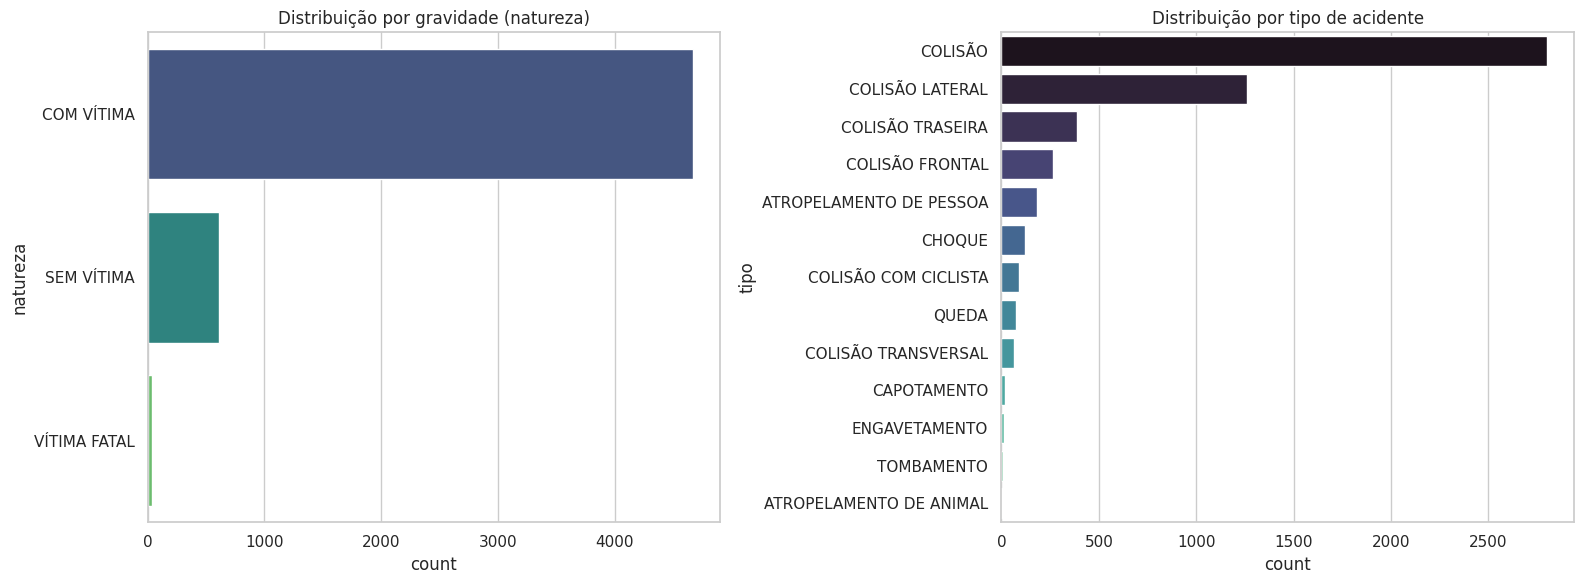

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# distribuição da variável 'natureza' com vítima, sem vítima..
sns.countplot(data=df, y='natureza', ax=axes[0], order=df['natureza'].value_counts().index, palette='viridis')
axes[0].set_title('Distribuição por gravidade (natureza)')

# distribuição da variável 'tipo' colisão lateral, capotamento...
sns.countplot(data=df, y='tipo', ax=axes[1], order=df['tipo'].value_counts().index, palette='mako')
axes[1].set_title('Distribuição por tipo de acidente')

plt.tight_layout()
plt.show()

**Análise da distribuição das variáveis numéricas**

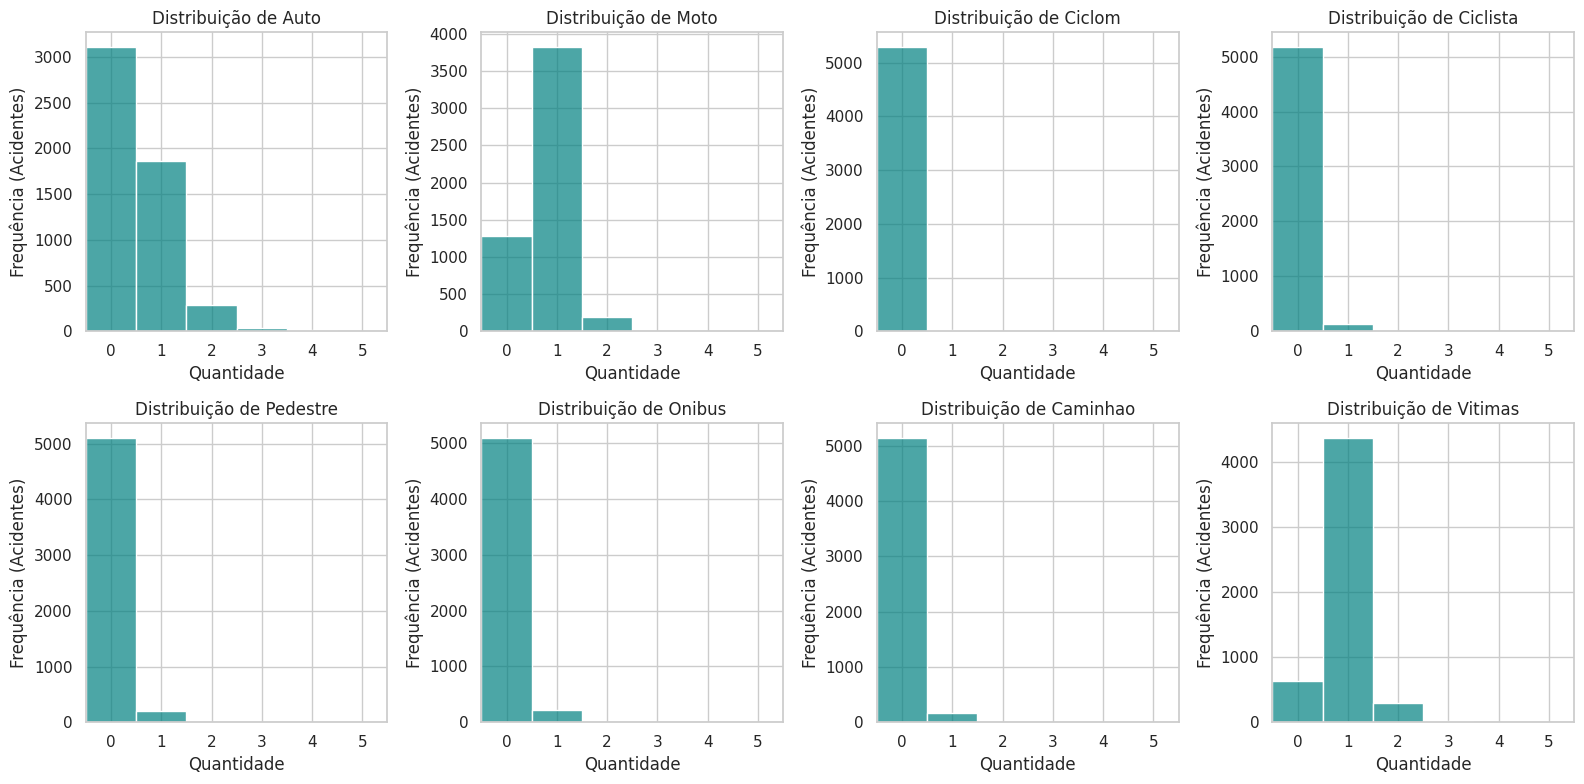

In [52]:
cols_numericas = ['auto', 'moto', 'ciclom', 'ciclista', 'pedestre', 'onibus', 'caminhao', 'vitimas']

plt.figure(figsize=(16, 8))

# loop p plotar o histograma de cada coluna numérica
for i, col in enumerate(cols_numericas, 1):
    plt.subplot(2, 4, i)
    sns.histplot(data=df, x=col, discrete=True, color='teal', alpha=0.7)

    plt.title(f'Distribuição de {col.capitalize()}')
    plt.xlabel('Quantidade')
    plt.ylabel('Frequência (Acidentes)')
    plt.xlim(-0.5, 5.5)

plt.tight_layout()
plt.show()

**Análise bivariada (cruzando variáveis)**

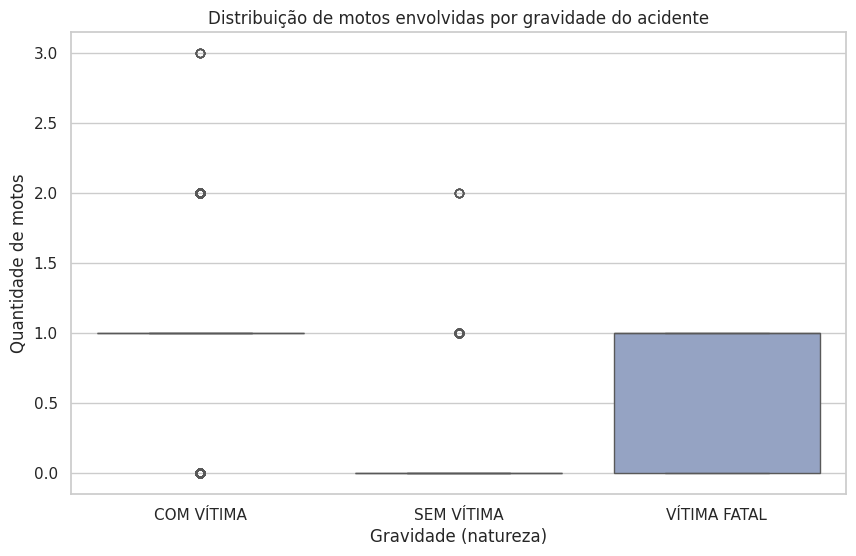

In [53]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='natureza', y='moto', hue='natureza', palette='Set2', legend=False)
plt.title('Distribuição de motos envolvidas por gravidade do acidente')
plt.xlabel('Gravidade (natureza)')
plt.ylabel('Quantidade de motos')
plt.show()

**Identificando outliers nas variáveis numéricas**

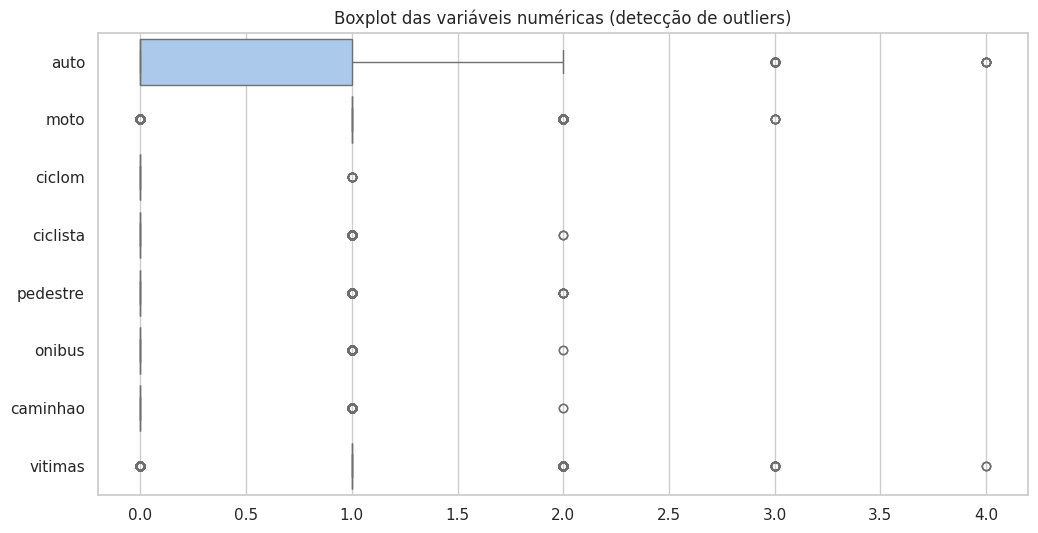

In [54]:
# colunas numéricas
cols_numericas = ['auto', 'moto', 'ciclom', 'ciclista', 'pedestre', 'onibus', 'caminhao', 'vitimas']

# plotando Boxplots direto do df original
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[cols_numericas], orient="h", palette="pastel")
plt.title("Boxplot das variáveis numéricas (detecção de outliers)")
plt.show()

**Analisando o desbalanceamento da variável alvo (Target)**


/tmp/ipykernel_9212/845915178.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='natureza', order=df['natureza'].value_counts().index, palette='viridis')


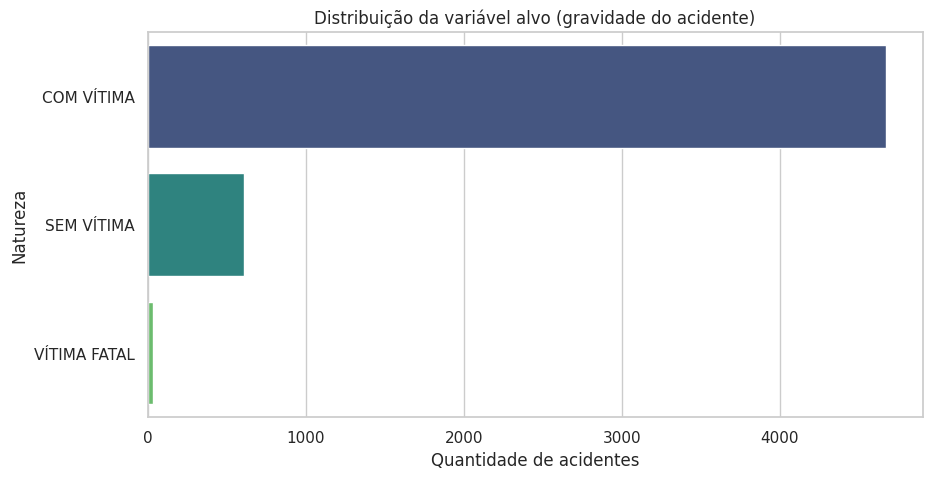

In [55]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='natureza', order=df['natureza'].value_counts().index, palette='viridis')

plt.title('Distribuição da variável alvo (gravidade do acidente)')
plt.xlabel('Quantidade de acidentes')
plt.ylabel('Natureza')
plt.show()

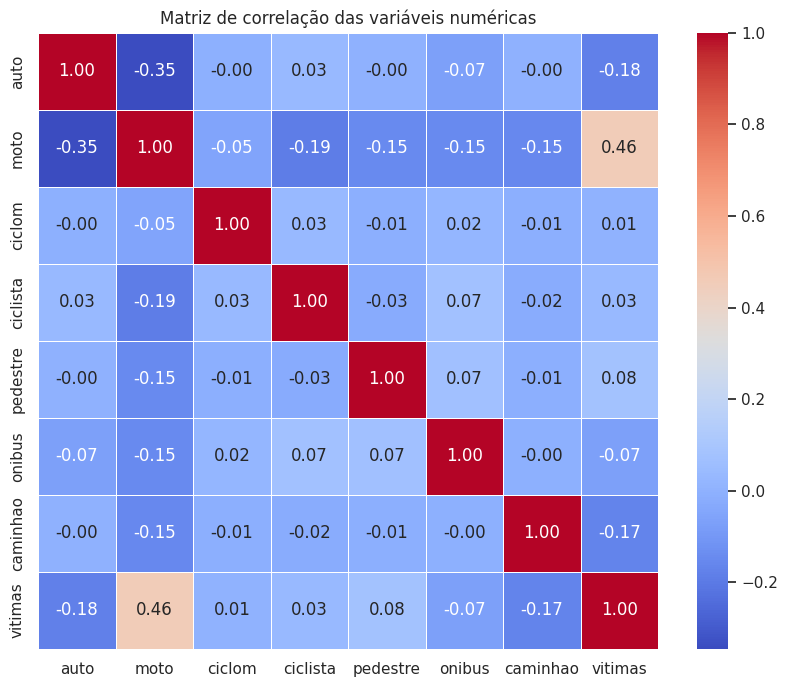

In [56]:
plt.figure(figsize=(10, 8))
corr_matrix = df[cols_numericas].corr()

# plotando o heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de correlação das variáveis numéricas')
plt.show()

**Análise dos bairros com maiores números de acidentes**

/tmp/ipykernel_9212/3370340889.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bairros.values, y=top_bairros.index, palette='viridis')


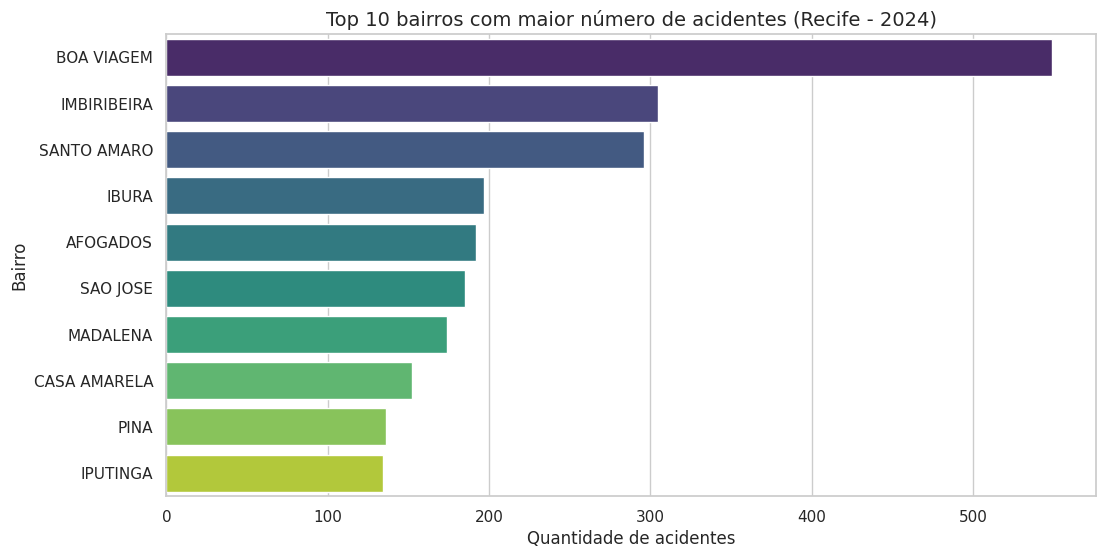

In [57]:
if 'bairro' in df.columns:
    plt.figure(figsize=(12, 6))
    bairros_validos = df[df['bairro'] != 'NÃO INFORMADO']
    top_bairros = bairros_validos['bairro'].value_counts().head(10)

    sns.barplot(x=top_bairros.values, y=top_bairros.index, palette='viridis')
    plt.title('Top 10 bairros com maior número de acidentes (Recife - 2024)', fontsize=14)
    plt.xlabel('Quantidade de acidentes')
    plt.ylabel('Bairro')
    plt.show()

**Tipos de acidentes mais comuns**

/tmp/ipykernel_9212/1976376075.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tipos.values, y=top_tipos.index, palette='magma')


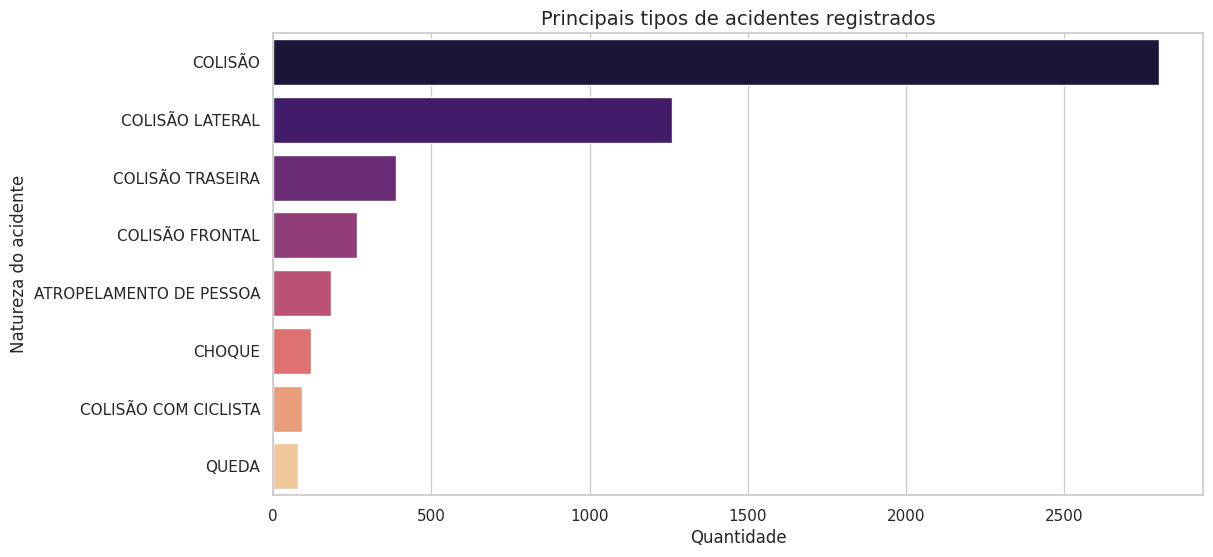

In [58]:
if 'tipo' in df.columns:
    plt.figure(figsize=(12, 6))
    tipos_validos = df[df['tipo'] != 'NÃO INFORMADO']
    top_tipos = tipos_validos['tipo'].value_counts().head(8)

    sns.barplot(x=top_tipos.values, y=top_tipos.index, palette='magma')
    plt.title('Principais tipos de acidentes registrados', fontsize=14)
    plt.xlabel('Quantidade')
    plt.ylabel('Natureza do acidente')
    plt.show()